# Introducción a las Ciencias Ómicas Espaciales
**Guía 1 de la serie · Transcriptómica espacial para ingeniería de sistemas y análisis de datos**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1y9Jpv2vh_QsyQS2Luii1jIV-oSzcJvLg)

### Objetivos
Al terminar esta guía podrás:
1. Explicar por qué la posición de una célula importa para lo que hace.
2. Describir los tres componentes de datos de un experimento espacial (**X**, **S**, **I**) y el grafo de vecindad que se construye a partir de ellos.
3. Inspeccionar un objeto `AnnData` espacial y saber dónde vive cada componente.
4. Construir un grafo de vecindad y justificar las decisiones de modelado que implica.

## 1. Motivación: ¿por qué importa el espacio?

Casi todas las células de un organismo comparten esencialmente el mismo genoma. Hay excepciones: las células sexuales tienen un único juego de cromosomas y pasan por recombinación; los linfocitos B y T reordenan segmentos de su ADN; los glóbulos rojos maduros no tienen núcleo ni ADN; y las células tumorales acumulan mutaciones.

Entonces, ¿por qué una neurona y un hepatocito hacen cosas tan distintas? Una analogía útil: **es el mismo código fuente, pero con distinto estado de ejecución.** La diferencia no está en qué genes existen, sino en **cuáles se activan (se expresan), en qué medida y en qué momento**.

Ese estado depende de señales químicas que la célula recibe, y muchas provienen de su entorno inmediato: moléculas secretadas por células vecinas, contacto directo, gradientes de oxígeno o de nutrientes. Por eso, la identidad y la función de una célula están **influenciadas** por su contexto espacial: quiénes son sus vecinas, a qué distancia están y qué moléculas intercambian en un punto del espacio 2D o 3D. (También influyen el linaje y el estado intrínseco de la célula; el espacio es una pieza, no la única.)

### ¿Qué medimos?
Los métodos que veremos miden principalmente **ARN mensajero (transcritos)**, y en algunos casos proteínas, **junto con las coordenadas** de dónde se midieron. Así se habla de transcriptómica espacial y proteómica espacial. (La genómica espacial también existe, pero mide ADN, no expresión.)

<img width="900" height="300" alt="Flujo de información y Ómicas" src="https://github.com/user-attachments/assets/8b7a3008-cda9-4b05-ab90-efc634a4817b" />

## 2. La abstracción: del tejido a las estructuras de datos

Un corte de tejido puede verse como una fuente **no estructurada**. La transcriptómica espacial lo abstrae en tres componentes:

| Componente | Símbolo | Forma | Qué representa |
|---|---|---|---|
| Matriz de expresión | $\mathbf{X}$ | $N \times M$ | Abundancia de cada gen en cada unidad de muestreo |
| Coordenadas espaciales | $\mathbf{S}$ | $N \times 2$ | Posición $(x_i, y_i)$ de cada unidad |
| Imagen histológica | $\mathbf{I}$ | $H \times W \times C$ | Contexto morfológico (tinción H&E o inmunofluorescencia) |

A partir de $\mathbf{S}$ se construye además un **grafo espacial de vecindad** $G = (V, E)$, donde los nodos son las unidades de muestreo y las aristas representan proximidad física.

Usaremos **un solo dataset** durante toda la guía para ver cada componente en un objeto real.

In [ ]:
# TODO: fijar versiones (p. ej. scanpy==X.Y.Z squidpy==X.Y.Z) después de probar
# el notebook en un runtime limpio de Colab.
!pip install -q scanpy squidpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scanpy as sc
import squidpy as sq

sc.settings.verbosity = 1
print("scanpy", sc.__version__, "| squidpy", sq.__version__)

scanpy 1.12.4 | squidpy 1.8.3


/tmp/ipykernel_1645/756432717.py:9: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__, "| squidpy", sq.__version__)


## 3. Nuestro dataset de trabajo

Usaremos un corte de **cerebro de ratón** medido con la tecnología **Visium** (10x Genomics), que viene incluido en `squidpy`. Se eligió porque su anatomía es reconocible (regiones bien delimitadas) y es liviano para Colab.

In [ ]:
adata = sq.datasets.visium_hne_adata()
adata

INFO     Downloading visium_hne_adata.h5ad from https://exampledata.scverse.org/squidpy/visium_hne_adata.h5ad      


  0%|                                               | 0.00/329M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

Lo que ves es un objeto **`AnnData`**: un contenedor único que agrupa los componentes. Lo desarmaremos pieza por pieza y al final volveremos a él.

## 4. Componente 1: la matriz de expresión $\mathbf{X}$

$\mathbf{X} \in \mathbb{R}_{\ge 0}^{N \times M}$ guarda la abundancia de cada molécula medida.

* **Filas ($N$ observaciones):** unidades de muestreo espacial (una célula, un *spot* o un área delimitada).
* **Columnas ($M$ características):** genes (o proteínas) medidos. En transcriptoma completo, $M > 20{,}000$; en paneles dirigidos, entre cientos y unos pocos miles.
* **Valores:** conteos enteros de moléculas antes de normalizar; valores reales después.

In [ ]:
X = adata.X
print("Tipo:", type(X))
print("Forma (N observaciones × M genes):", adata.shape)
print("¿Matriz dispersa (sparse)?", sp.issparse(X))

Tipo: <class 'scipy.sparse._csr.csr_matrix'>
Forma (N observaciones × M genes): (2688, 18078)
¿Matriz dispersa (sparse)? True


In [ ]:
# Un vistazo a una esquina de la matriz
pd.DataFrame(
    X[:5, :5].toarray() if sp.issparse(X) else X[:5, :5],
    index=adata.obs_names[:5],
    columns=adata.var_names[:5],
)

,Xkr4,Sox17,Mrpl15,Lypla1,Tcea1
AAACAAGTATCTCCCA-1,0.0,0.0,0.878931,0.878931,1.339373
AAACAATCTACTAGCA-1,0.0,0.0,1.092216,1.092216,1.092216
AAACACCAATAACTGC-1,0.0,0.0,0.000000,0.000000,0.980359
AAACAGAGCGACTCCT-1,0.0,0.0,0.000000,0.000000,0.000000
AAACCGGGTAGGTACC-1,0.0,0.0,0.996971,0.000000,0.617901


### El reto de datos: alta dimensión y dispersión (*sparsity*)
La matriz tiene muchas columnas y **la mayoría de sus entradas son cero**. Parte de esos ceros es técnica (la molécula estaba pero no se detectó) y parte es biológica (el gen realmente no se expresa en ese lugar). Distinguirlas no es trivial. Por eso estas matrices se almacenan como **matrices dispersas** (`scipy.sparse`).

In [ ]:
n_total = adata.n_obs * adata.n_vars
n_nonzero = X.nnz if sp.issparse(X) else np.count_nonzero(X)
print(f"Fracción de ceros: {1 - n_nonzero / n_total:.1%}")

vals = X.data if sp.issparse(X) else np.asarray(X).ravel()
print("Mínimo:", vals.min(), "| Máximo:", vals.max())
print("¿Todos los valores son enteros?", np.allclose(vals, np.round(vals)))

Fracción de ceros: 68.3%
Mínimo: 0.16780251 | Máximo: 8.859275
¿Todos los valores son enteros? False


> **Pregunta:** según la última línea, ¿este `X` contiene conteos crudos o valores ya normalizados? ¿Qué implicaría cada caso para un análisis posterior? (Lo retomamos en la guía de preprocesamiento.)

### ¿Qué es exactamente una fila? Spot ≠ célula
Este punto es central: **el significado de una fila de $\mathbf{X}$ depende de la tecnología.**

| Familia | Ejemplos | Una fila es... | Genes medidos |
|---|---|---|---|
| Basadas en secuenciación | Visium, Visium HD, Stereo-seq | un *spot* o *bin* (puede contener varias células) | transcriptoma completo |
| Basadas en imagen | Xenium, MERFISH, CosMx | típicamente una célula segmentada | panel dirigido |

En Visium cada spot mide unos 55 µm de diámetro y puede contener una o varias células, así que su perfil de expresión es una **mezcla**. Existen métodos de *deconvolución* para estimar qué tipos celulares componen cada spot.

## 5. Componente 2: las coordenadas $\mathbf{S}$

$\mathbf{S} \in \mathbb{R}^{N \times 2}$ ubica cada observación $n_i$ en un plano $(x_i, y_i)$, en micrómetros o en píxeles:

$$\mathbf{S} = \begin{bmatrix} x_1 & y_1 \\ x_2 & y_2 \\ \vdots & \vdots \\ x_N & y_N \end{bmatrix}$$

In [ ]:
S = adata.obsm["spatial"]
print("Forma de S:", S.shape)
print(S[:5])

Forma de S: (2688, 2)
[[8230 7237]
 [4170 1611]
 [2519 8315]
 [7679 2927]
 [3138 6280]]


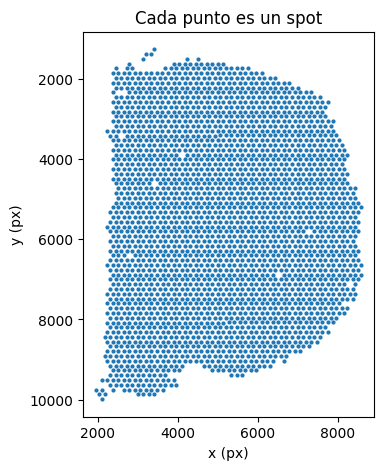

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(S[:, 0], S[:, 1], s=4)
ax.invert_yaxis()  # convención de imagen: el origen (0, 0) está arriba a la izquierda
ax.set_aspect("equal")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
ax.set_title("Cada punto es un spot")
plt.show()

### ¿Píxeles o micrómetros?
Las coordenadas suelen venir en **píxeles de la imagen original**. Para hablar de distancias biológicas hay que convertirlas usando un factor de escala. En Visium sabemos que el spot mide ~55 µm, y el factor de escala nos dice cuántos píxeles ocupa.

In [ ]:
lib_id = list(adata.uns["spatial"].keys())[0]
sf = adata.uns["spatial"][lib_id]["scalefactors"]
print(sf)

um_per_px = 55 / sf["spot_diameter_fullres"]  # el spot de Visium mide ~55 µm
S_um = S * um_per_px

# Comprobación de cordura: distancia al vecino más cercano (en µm)
from scipy.spatial import cKDTree
d, _ = cKDTree(S_um).query(S_um, k=2)
print(f"Distancia mediana al vecino más cercano: {np.median(d[:, 1]):.0f} µm")

{'fiducial_diameter_fullres': np.float64(144.48769000651953), 'spot_diameter_fullres': np.float64(89.44476048022638), 'tissue_hires_scalef': np.float64(0.17011142), 'tissue_lowres_scalef': np.float64(0.051033426)}
Distancia mediana al vecino más cercano: 84 µm


## 6. Componente 3: la imagen histológica $\mathbf{I}$

$\mathbf{I} \in \mathbb{R}^{H \times W \times C}$ es la capa de contexto morfológico (tinción H&E o inmunofluorescencia). $H \times W$ es la resolución en píxeles y $C$ el número de canales (3 en una imagen a color).

Para usarla junto con $\mathbf{S}$ se necesita un **registro de coordenadas**: alinear el sistema de coordenadas de los spots con el de la imagen, típicamente mediante un factor de escala (y, en algunas tecnologías, transformaciones adicionales).

Resoluciones disponibles: ['hires', 'lowres']
Forma de I (H × W × C): (2000, 1921, 3) | dtype: float32


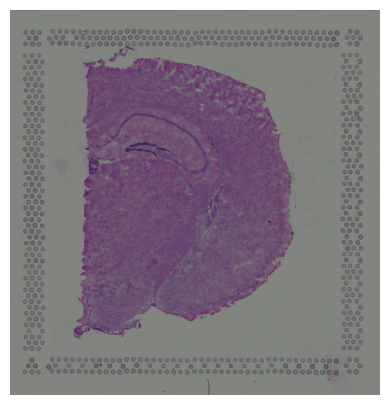

In [ ]:
img_dict = adata.uns["spatial"][lib_id]["images"]
print("Resoluciones disponibles:", list(img_dict.keys()))

I = img_dict["hires"]
print("Forma de I (H × W × C):", I.shape, "| dtype:", I.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(I)
plt.axis("off")
plt.show()

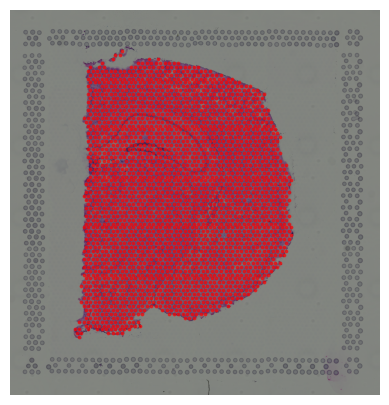

In [12]:
# Registro de coordenadas en acción: superponemos S sobre I
s = sf["tissue_hires_scalef"]  # de píxeles "full-res" a píxeles de la imagen hires

plt.figure(figsize=(5, 5))
plt.imshow(I)
plt.scatter(S[:, 0] * s, S[:, 1] * s, s=3, c="red", alpha=0.6)
plt.axis("off")
plt.show()

### Los tres componentes juntos
Con las coordenadas y la imagen alineadas, podemos ver la expresión de un gen **sobre el tejido**. Esto es lo que distingue a estos datos de un experimento de RNA-seq convencional.

/usr/local/lib/python3.13/dist-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


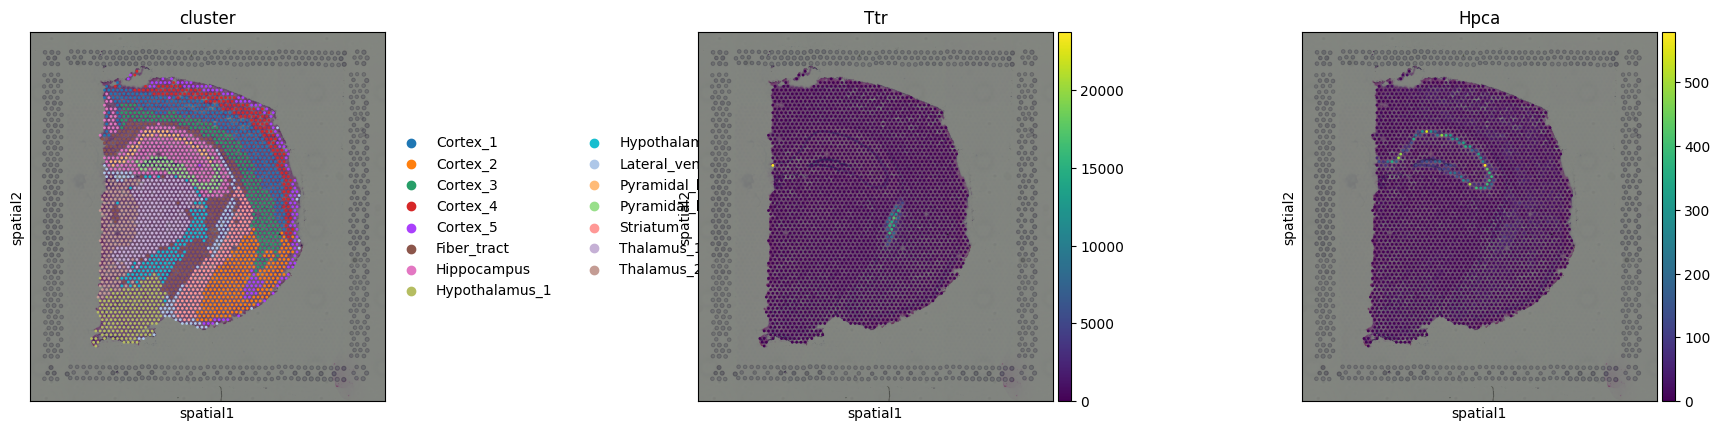

In [ ]:
genes = [g for g in ["Ttr", "Hpca"] if g in adata.var_names]
color = [c for c in ["cluster"] if c in adata.obs] + genes
sq.pl.spatial_scatter(adata, color=color)

## 7. El grafo espacial de vecindad $G = (V, E)$

Al cruzar $\mathbf{S}$ con $\mathbf{X}$, la muestra se convierte en un grafo: los **nodos** $V$ son las unidades de muestreo y las **aristas** $E$ representan proximidad física.

**Ojo:** el grafo *no viene dado por los datos*. Es una **decisión de modelado**. Las reglas más comunes son:

| Regla | Idea | Cuándo suele usarse |
|---|---|---|
| Rejilla (*grid*) | vecinos inmediatos en la retícula del instrumento | Visium (rejilla hexagonal, 6 vecinos) |
| k vecinos más cercanos | conecta cada nodo con sus $k$ más cercanos | datos con posiciones irregulares (células) |
| Radio fijo | conecta todo lo que esté a menos de una distancia | cuando la escala biológica importa |
| Triangulación de Delaunay | conecta según una teselación del plano | posiciones irregulares, sin elegir $k$ |

In [13]:
sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)  # Visium: rejilla hexagonal
A = adata.obsp["spatial_connectivities"]
print(type(A))
print("Forma de A:", A.shape, "| aristas (dirigidas):", A.nnz)

INFO     Creating graph using `None` transform and `1` libraries.                                                  
<class 'scipy.sparse._csr.csr_matrix'>
Forma de A: (2688, 2688) | aristas (dirigidas): 15580


/tmp/ipykernel_1645/640891857.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)  # Visium: rejilla hexagonal


In [14]:
# Grado de cada nodo (número de vecinos)
deg = np.asarray(A.sum(axis=1)).ravel()
pd.Series(deg).value_counts().sort_index()

1.0       3
2.0      18
3.0      62
4.0      77
5.0     121
6.0    2407
Name: count, dtype: int64

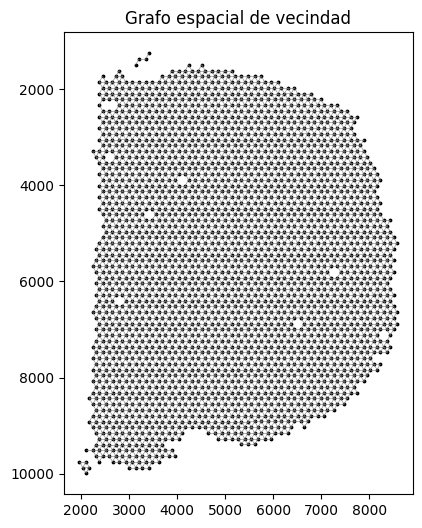

In [15]:
# Dibujamos el grafo
from matplotlib.collections import LineCollection

rows, cols = A.nonzero()
mask = rows < cols  # cada arista una sola vez
segs = np.stack([S[rows[mask]], S[cols[mask]]], axis=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(LineCollection(segs, linewidths=0.4, colors="gray"))
ax.scatter(S[:, 0], S[:, 1], s=3, c="black")
ax.autoscale()
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title("Grafo espacial de vecindad")
plt.show()

In [16]:
# Otras reglas para el mismo tejido (guardadas con otro nombre para no sobrescribir)
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6, key_added="knn6")
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True, key_added="delaunay")

for k in ["spatial", "knn6", "delaunay"]:
    M_ = adata.obsp[f"{k}_connectivities"]
    print(f"{k:>9} → aristas: {M_.nnz}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
  spatial → aristas: 15580
     knn6 → aristas: 16128
 delaunay → aristas: 16070


/tmp/ipykernel_1645/2215345774.py:2: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6, key_added="knn6")
/tmp/ipykernel_1645/2215345774.py:3: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True, key_added="delaunay")


## 8. El contenedor unificado: `AnnData` / `SpatialExperiment`

Ecosistemas como Python (`Scanpy` / `Squidpy`) y R (`Bioconductor`) guardan todo lo anterior en **un único objeto**. Así se corresponde cada componente con un atributo del `AnnData`:

| Atributo | Contiene | Componente |
|---|---|---|
| `.X` | matriz de expresión ($N \times M$) | $\mathbf{X}$ |
| `.obs` | metadatos de observaciones (una fila por spot/célula) | |
| `.var` | metadatos de genes (una fila por gen) | |
| `.obsm['spatial']` | coordenadas $(x, y)$ ($N \times 2$) | $\mathbf{S}$ |
| `.uns['spatial']` | imagen H&E y factores de escala | $\mathbf{I}$ |
| `.obsp[...]` | grafos de vecindad ($N \times N$, dispersos) | $G$ |

In [17]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'spatial_neighbors', 'knn6_neighbors', 'delaunay_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'knn6_con

In [18]:
display(adata.obs.head())
display(adata.var.head())

,in_tissue,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,leiden,cluster
AAACAAGTATCTCCCA-1,1,50,102,4928,8.502891,19340.0,9.869983,38.428128,43.133402,49.214064,60.449845,3857.0,8.257904,19.943123,19340.0,2,Cortex_2
AAACAATCTACTAGCA-1,1,3,43,3448,8.145840,13750.0,9.528867,50.516364,55.141818,60.952727,70.574545,3267.0,8.091933,23.760000,13750.0,11,Cortex_5
AAACACCAATAACTGC-1,1,59,19,6022,8.703341,32710.0,10.395467,40.483033,47.071232,54.564353,65.087129,4910.0,8.499233,15.010699,32710.0,7,Thalamus_2
AAACAGAGCGACTCCT-1,1,14,94,4311,8.369157,15909.0,9.674704,40.957948,45.810547,52.077440,62.976931,3270.0,8.092851,20.554403,15909.0,11,Cortex_5
AAACCGGGTAGGTACC-1,1,42,28,5787,8.663542,31856.0,10.369013,40.287544,45.887745,52.982170,64.248493,6693.0,8.808967,21.010170,31856.0,7,Thalamus_2


,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,False,233,0.093032,0.088955,91.363973,251.0,5.529429,233,False,NaN,0.093378,0.098832,0.815019
Sox17,ENSMUSG00000025902,Gene Expression,mm10,False,298,0.128243,0.120662,88.954781,346.0,5.849325,298,False,NaN,0.128720,0.156108,0.931378
Mrpl15,ENSMUSG00000033845,Gene Expression,mm10,False,1775,1.370645,0.863162,34.210526,3698.0,8.215817,1775,False,NaN,1.375744,2.163193,0.850736
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,False,1294,0.741290,0.554626,52.038547,2000.0,7.601402,1293,False,NaN,0.743676,0.984143,0.873699
Tcea1,ENSMUSG00000033813,Gene Expression,mm10,False,1975,1.727947,1.003549,26.797628,4662.0,8.447414,1974,False,NaN,1.734003,3.030447,0.856292


## 9. Contraste: cuando cada fila es una célula

Para reforzar que $N$, $M$ y el significado de una fila cambian con la tecnología, carguemos un dataset de **MERFISH** (basado en imagen, resolución celular, panel dirigido). La descarga puede tardar un poco más.

In [19]:
adata_mf = sq.datasets.merfish()
print("MERFISH → filas (N):", adata_mf.n_obs, "| columnas (M):", adata_mf.n_vars)
print("Visium  → filas (N):", adata.n_obs, "| columnas (M):", adata.n_vars)
adata_mf

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/merfish.h5ad                        


  0%|                                              | 0.00/51.6M [00:00<?, ?B/s]

MERFISH → filas (N): 73655 | columnas (M): 161
Visium  → filas (N): 2688 | columnas (M): 18078


AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'
    layers: None (.X)

> **Pregunta:** compara las dos formas. ¿Cuál tiene más filas? ¿Cuál más columnas? ¿Por qué?

## 10. Ejercicios

**Ejercicio 1.** Calcula, para cada gen del dataset de Visium, en qué fracción de spots se detecta (valor > 0). ¿Cuántos genes se detectan en menos del 1 % de los spots?

<details>
<summary>Ver solución</summary>

```python
nz_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
frac = nz_per_gene / adata.n_obs
print((frac < 0.01).sum())
```
</details>

**Ejercicio 2.** Sin usar `squidpy`, grafica con `matplotlib` la expresión de un gen sobre las coordenadas (color = nivel de expresión).

<details>
<summary>Ver solución</summary>

```python
g = "Ttr"
v = X[:, adata.var_names.get_loc(g)]
v = v.toarray().ravel() if sp.issparse(v) else np.asarray(v).ravel()

fig, ax = plt.subplots(figsize=(5, 5))
sc_ = ax.scatter(S[:, 0], S[:, 1], c=v, s=6, cmap="viridis")
ax.invert_yaxis()
ax.set_aspect("equal")
plt.colorbar(sc_, label=g)
plt.show()
```
</details>

**Ejercicio 3.** Calcula la memoria que ocupa `X` como matriz dispersa y compárala con la que ocuparía como matriz densa. ¿Por qué esto importa?

<details>
<summary>Ver solución</summary>

```python
if sp.issparse(X):
    mem_sparse = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
else:
    mem_sparse = X.nbytes
mem_dense = adata.n_obs * adata.n_vars * X.dtype.itemsize
print(f"Actual: {mem_sparse/1e6:.1f} MB | Densa: {mem_dense/1e6:.1f} MB")
```
Importa porque con decenas o cientos de miles de observaciones, la versión densa puede no caber en memoria.
</details>

**Ejercicio 4.** Construye el grafo con $k = 4$, $6$ y $12$ vecinos (regla `generic`). ¿Cómo cambia el número de aristas y la distribución de grados? ¿Qué implica elegir $k$ muy grande para lo que consideramos "vecindad"?

<details>
<summary>Ver pista</summary>

Usa `key_added` distinto en cada llamada para no sobrescribir los grafos anteriores. Con $k$ grande, nodos que están lejos quedan conectados y se diluye la noción de contexto **local**.
</details>

**Ejercicio 5 (conceptual).** En Visium un spot puede contener varias células. ¿Qué limitación tiene interpretar la expresión de un spot como si fuera la de una célula?

<details>
<summary>Ver respuesta</summary>

El perfil del spot es una mezcla de los perfiles de todas las células que contiene, así que una señal observada no se puede atribuir a un tipo celular específico sin más información. Por eso se usan métodos de deconvolución o tecnologías de resolución celular.
</details>

## 11. Glosario

| Término | Significado |
|---|---|
| Transcrito | molécula de ARN producida a partir de un gen |
| Expresión génica | medida de cuánto se "activa" un gen |
| Conteo | número de moléculas detectadas de un gen en una observación |
| Dispersión (*sparsity*) | proporción de ceros en la matriz |
| Spot | zona circular del chip donde se captura ARN (puede contener varias células) |
| Panel dirigido | lista acotada de genes que se miden a propósito |
| Registro de coordenadas | alineación entre el sistema de coordenadas de los spots y el de la imagen |
| `AnnData` | objeto de Python que agrupa matriz, metadatos, coordenadas e imagen |